In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv("vgsales.csv")

## Seaborn - Histogram with KDE

You want to understand **how a numerical variable is distributed**.

Example: `Global_Sales`.

#### Basic Syntax

```python
sns.histplot(data, bins=number_of_bins)
```

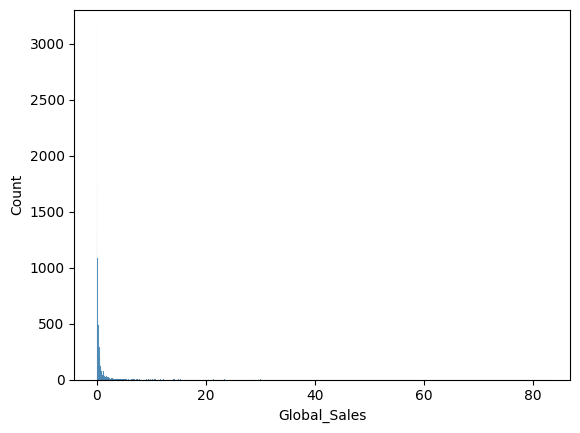

In [5]:
sns.histplot(df["Global_Sales"])
plt.show()

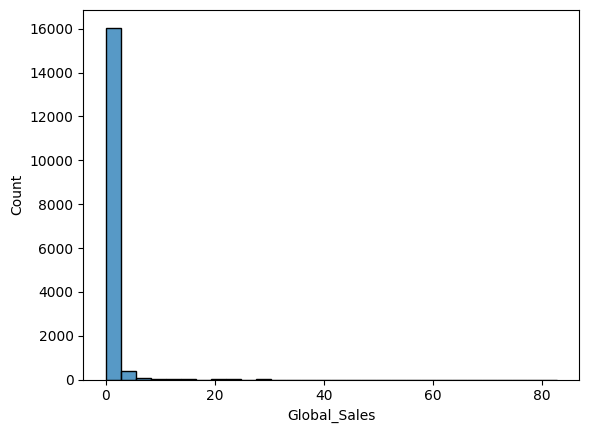

In [ ]:
# You can add bins too (More bins, more detailed View)

sns.histplot(df["Global_Sales"], bins=30)
plt.show()

#### Adding KDE (Important)

KDE = **Kernel Density Estimate**

It adds a **smooth curve** that shows the probability distribution.

Syntax:

```python
sns.histplot(df["Global_Sales"], bins=30, kde=True)
```

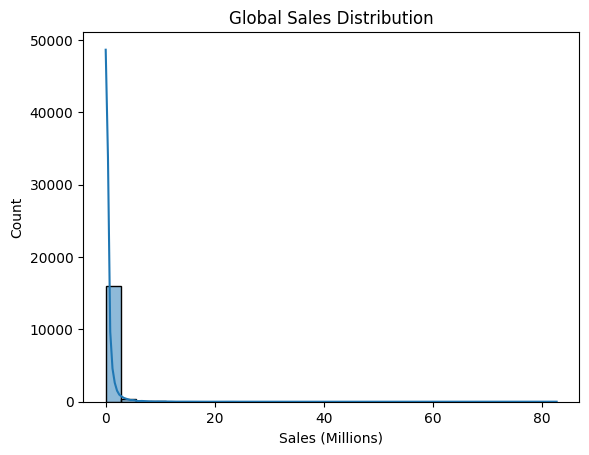

In [14]:
sns.histplot(df["Global_Sales"], bins=30, kde=True)

plt.title("Global Sales Distribution")
plt.xlabel("Sales (Millions)")
plt.ylabel("Count")

plt.show()

#### What You Should Observe

For your dataset you should see:

* huge spike near **0**
* long **right tail**
* few extreme values

This confirms what you already discovered from `describe()`.

Your dataset is **heavily right skewed**.

<Axes: xlabel='Global_Sales', ylabel='Count'>

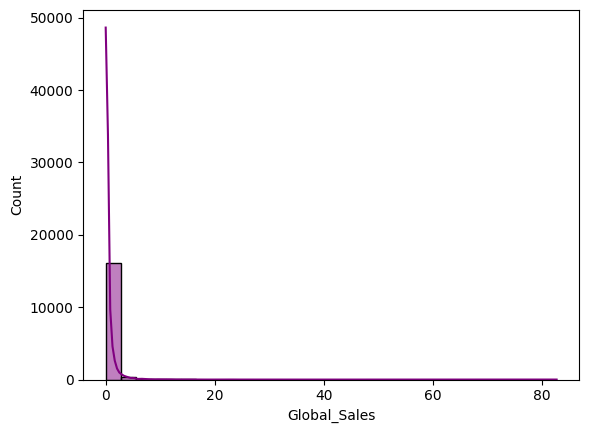

In [15]:
sns.histplot(df["Global_Sales"], bins=30, kde=True, color="purple")

<Axes: xlabel='Global_Sales', ylabel='Count'>

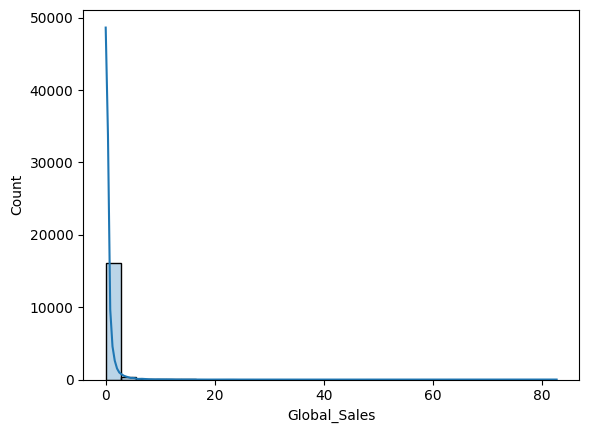

In [ ]:
sns.histplot(df["Global_Sales"], bins=30, kde=True, alpha=0.3) # you can change the transparency

## Seaborn - Count Plot

This one is used for **categorical data**.

It simply **counts how many times each category appears**.

hink of it as an automatic **frequency counter + bar chart**.

Example question:

> How many games exist in each **Genre**?

---

#### Basic Syntax

```python
sns.countplot(x="column_name", data=df)
```

Meaning:

```text
x → categorical column
data → dataset
```

---

<Axes: xlabel='Genre', ylabel='count'>

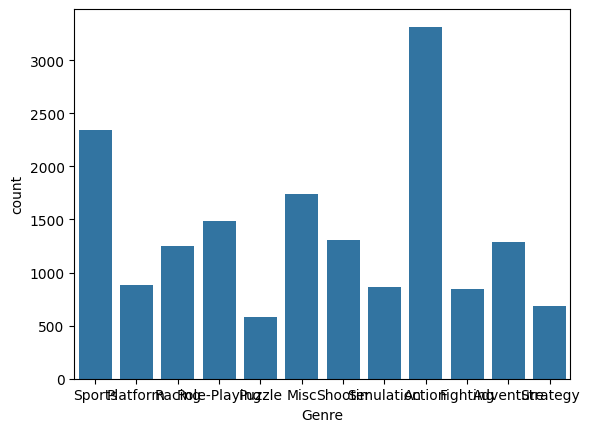

In [ ]:
sns.countplot(x="Genre",data=df)

# here problems you face is overlapping of x ticks lets fix it

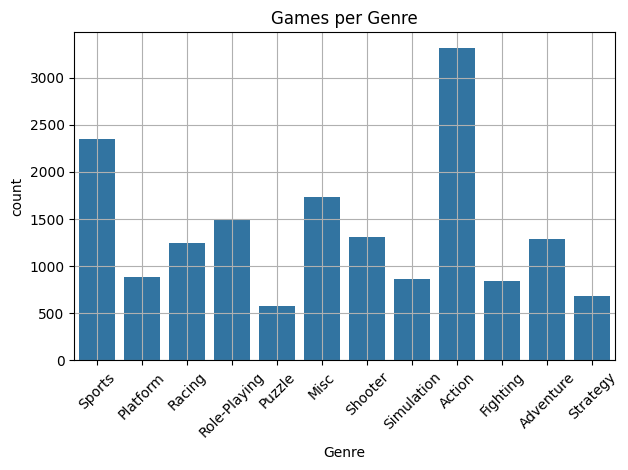

In [20]:
sns.countplot(x="Genre", data=df)

plt.title("Games per Genre")
plt.xticks(rotation=45)

plt.grid()
plt.tight_layout()
plt.show()

C:\Users\Ameyu\AppData\Local\Temp\ipykernel_5196\1507295509.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Genre", data=df, palette="viridis")


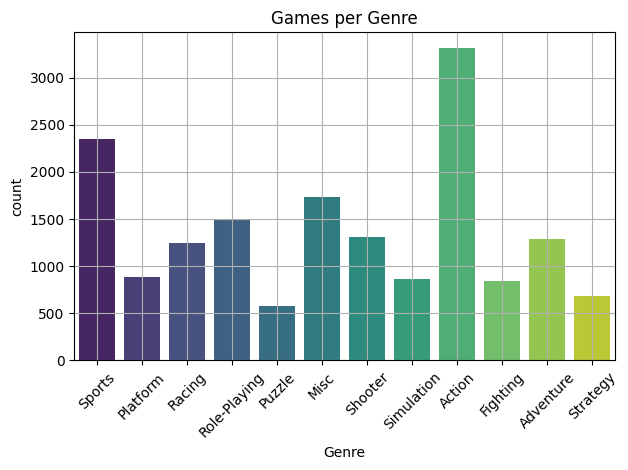

' \nCommon palettes:\nviridis\nmagma\ncoolwarm\nSet2\npastel\n'

In [24]:
# Adding Colors


sns.countplot(x="Genre", data=df, palette="viridis")

plt.title("Games per Genre")
plt.xticks(rotation=45)

plt.grid()
plt.tight_layout()
plt.show()
""" 
Common palettes:
viridis
magma
coolwarm
Set2
pastel
"""

### When To Use countplot()

1. Use it when analyzing:

2. Genre distribution

3. Platform popularity

4. Publisher frequency

5. Game ratings categories

6. Basically any categorical column.

## Seaborn - Box Plot

A **boxplot** helps you see:

* Median
* Quartiles (Q1, Q3)
* Spread of data
* Outliers

It’s one of the **best plots for detecting outliers and comparing distributions**.

---

#### Basic Syntax

```python
sns.boxplot(x=data)
```

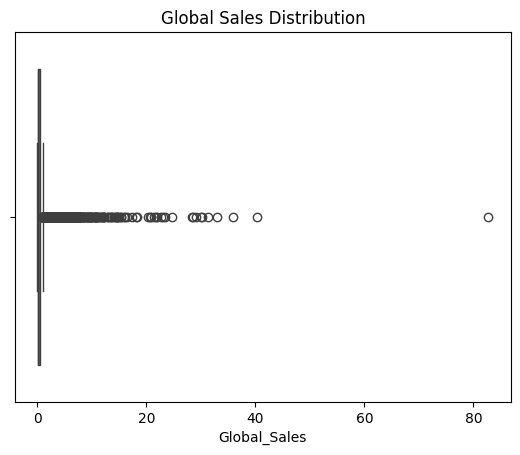

In [26]:
sns.boxplot(x=df["Global_Sales"])

plt.title("Global Sales Distribution")

plt.show()

Explanation:

* **Middle line** → median
* **Box edges** → Q1 and Q3
* **Whiskers** → range of typical values
* **Dots outside** → outliers

In your dataset you will see **many outliers**.

That’s expected because blockbuster games sell extremely high.

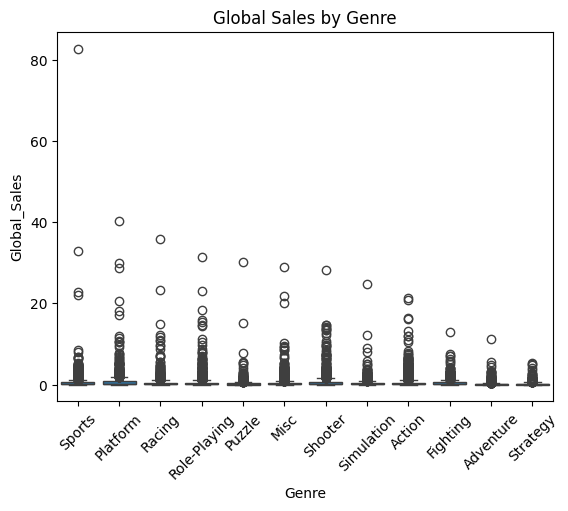

In [27]:
sns.boxplot(x="Genre", y="Global_Sales", data=df)

plt.xticks(rotation=45)
plt.title("Global Sales by Genre")

plt.show()

#### When to Use Boxplots

Use them when you want to:

* detect outliers
* compare distributions across categories
* see spread of values
* analyze median differences

Example questions you can answer:

* Which genre produces the biggest hits?
* Which genre has consistent sales?

## Seaborn - Scatter Plot


Scatter plots help answer questions like:

* Does **NA sales influence global sales?**
* Are two variables **positively correlated?**
* Are there **clusters or patterns** in the data?

---

#### Basic Syntax

```python
sns.scatterplot(x="column1", y="column2", data=df)
```

Meaning:

```
x → first numerical variable
y → second numerical variable
data → dataset
```

---

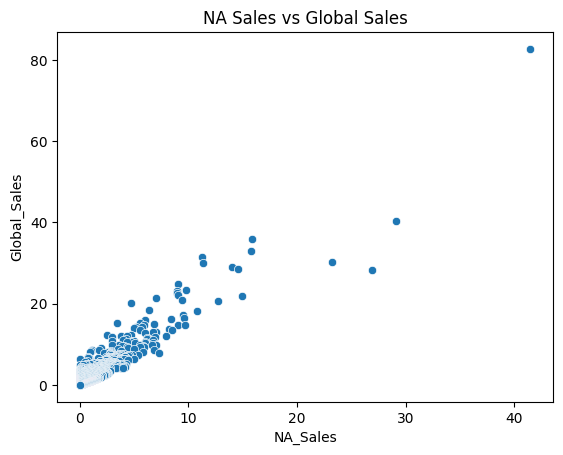

In [28]:
sns.scatterplot(x="NA_Sales", y="Global_Sales", data=df)

plt.title("NA Sales vs Global Sales")

plt.show()

Each point represents **one game**.

```
(x, y) = (NA sales, Global sales)
```

If NA sales increase and global sales increase too, you’ll see **points moving upward diagonally**.

That indicates **positive correlation**.

You will likely see a strong pattern because:

```
Global Sales ≈ NA + EU + JP + Other
```

So NA contributes heavily.

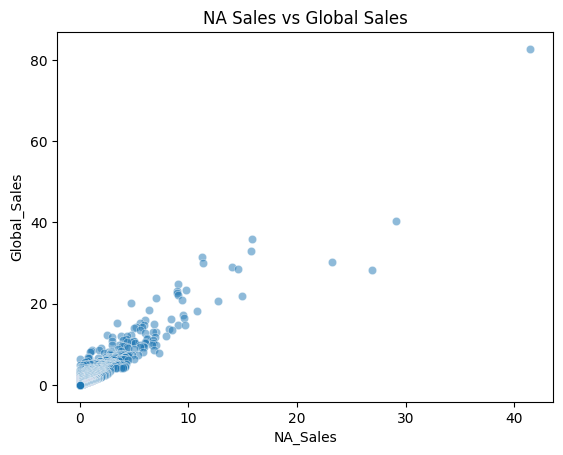

In [ ]:
sns.scatterplot(
    x="NA_Sales",
    y="Global_Sales",
    data=df,
    alpha=0.5 # Handling the transparency
)

plt.title("NA Sales vs Global Sales")

plt.show()

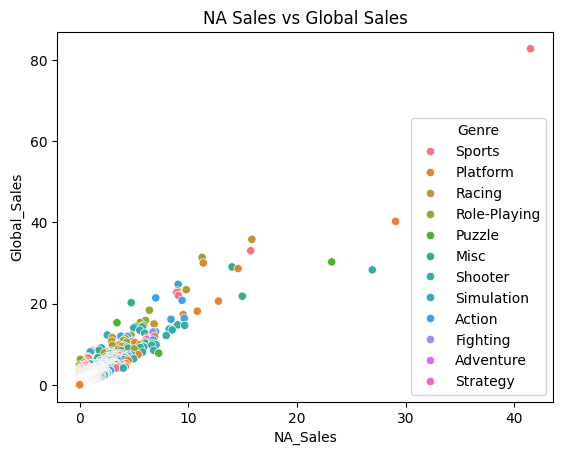

In [30]:
# Coloring by Category

sns.scatterplot(
    x="NA_Sales",
    y="Global_Sales",
    hue="Genre",
    data=df
)

plt.title("NA Sales vs Global Sales")

plt.show()

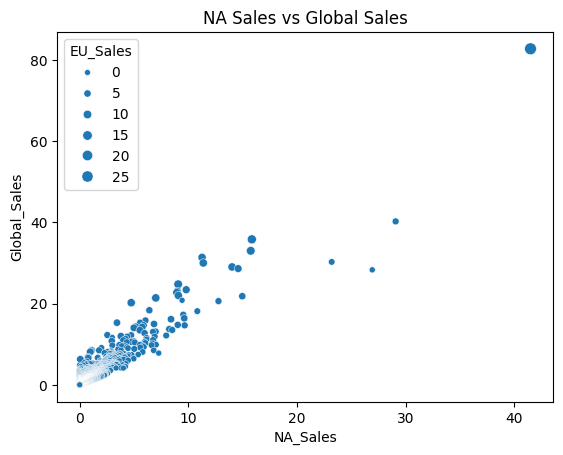

In [31]:
# Changing Marker Size

sns.scatterplot(
    x="NA_Sales",
    y="Global_Sales",
    size="EU_Sales",
    data=df
)

plt.title("NA Sales vs Global Sales")

plt.show()

#### When to Use Scatter Plots

Use them when analyzing:

* correlations
* relationships
* clusters
* trends

Common examples:

```
Advertising spend vs sales
House size vs price
Study hours vs exam score
```

---

## Seaborn - regplot

This one is basically a **scatter plot + regression line**.

It helps answer:

> Is there a **trend or relationship** between two variables?

Instead of guessing the trend visually, seaborn **fits a regression line automatically**.

#### Basic Syntax

```python
sns.regplot(x="column1", y="column2", data=df)
```

Meaning:

```
x → independent variable
y → dependent variable
data → dataset
```

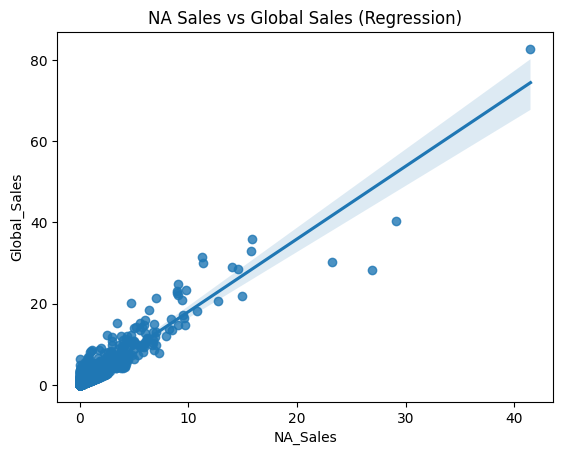

In [32]:
sns.regplot(x="NA_Sales", y="Global_Sales", data=df)

plt.title("NA Sales vs Global Sales (Regression)")

plt.show()

#### What This Plot Shows

You will see:

1. **scatter points**
2. **regression line**
3. **confidence interval band**

The **line shows the overall trend**.

If the line goes upward → **positive correlation**.

#### Confidence Interval (Shaded Area)

The shaded band around the line shows **uncertainty of the estimate**.

You can remove it:

```python
sns.regplot(x="NA_Sales", y="Global_Sales", data=df, ci=None)
```

`ci` = confidence interval.

#### When to Use `regplot`

Use it when you want to understand:

* direction of relationship
* strength of trend
* whether variables increase together

Common examples:

```
Advertising vs sales
Income vs spending
Study hours vs exam score
```

## Seaborn - Heatmap

A **heatmap** visualizes relationships between variables using **colors**.

It helps answer questions like:

* Which variables are strongly related?
* Which variables move together?
* Which variables have weak relationships?

#### Compute Correlation

First compute correlation between numerical columns.

```python
corr = df.corr()
```

This produces a **correlation matrix**.

In [34]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [36]:
corr = df[["Global_Sales","NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].corr()
corr

,Global_Sales,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Global_Sales,1.000000,0.941047,0.902836,0.611816,0.748331
NA_Sales,0.941047,1.000000,0.767727,0.449787,0.634737
EU_Sales,0.902836,0.767727,1.000000,0.435584,0.726385
JP_Sales,0.611816,0.449787,0.435584,1.000000,0.290186
Other_Sales,0.748331,0.634737,0.726385,0.290186,1.000000


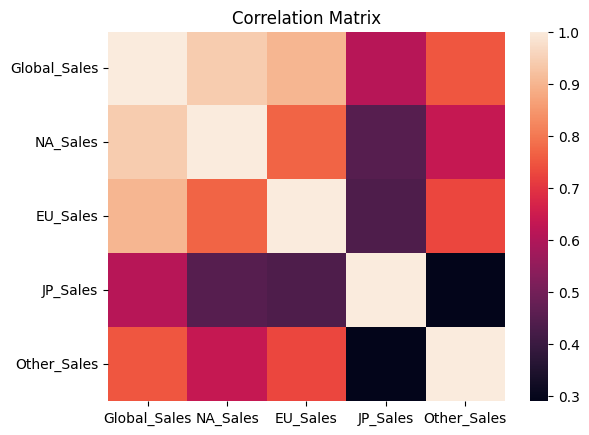

In [ ]:
# Plot the heap map

sns.heatmap(corr)

plt.title("Correlation Matrix")

plt.show()

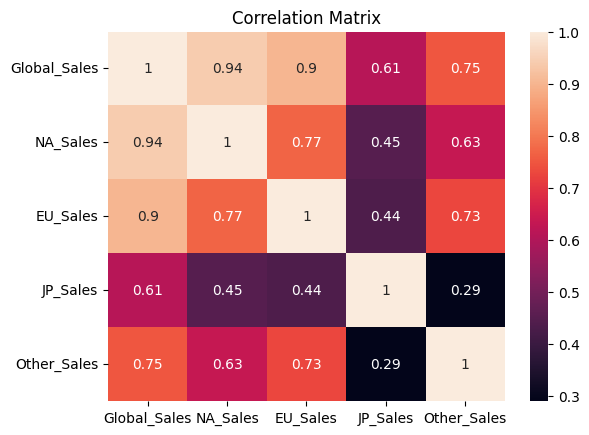

In [38]:
# Adding Numbers (Very Useful)

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.show()


'\nOther popular palettes:\n\ncoolwarm\nviridis\nmagma\nBlues\n'

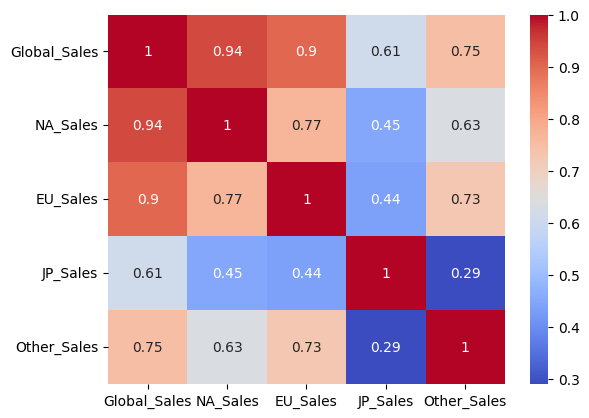

In [39]:
# Improving Readability

#Use a color palette.

sns.heatmap(corr, annot=True, cmap="coolwarm")

"""
Other popular palettes:

coolwarm
viridis
magma
Blues
"""

#### What You Should Observe

In your dataset, expect:

Strong correlations between:

```
NA_Sales
EU_Sales
JP_Sales
Global_Sales
```

Because:

```
Global_Sales = NA + EU + JP + Other
```

So correlations will be **very high (close to 1)**.

---

#### When Heatmaps Are Used

They are extremely useful for:

* feature selection
* detecting multicollinearity
* understanding relationships before ML

This is why heatmaps appear in **almost every ML project**.

---

## Seaborn - Pair Plot

A **pairplot** shows:

* Scatter plots between every pair of variables
* Distribution plots on the diagonal

It helps you quickly explore relationships in a dataset.

---

#### Basic Syntax

```python
sns.pairplot(dataframe)
```
But running this on the entire dataset may produce too many plots.

So we usually select **specific columns**.

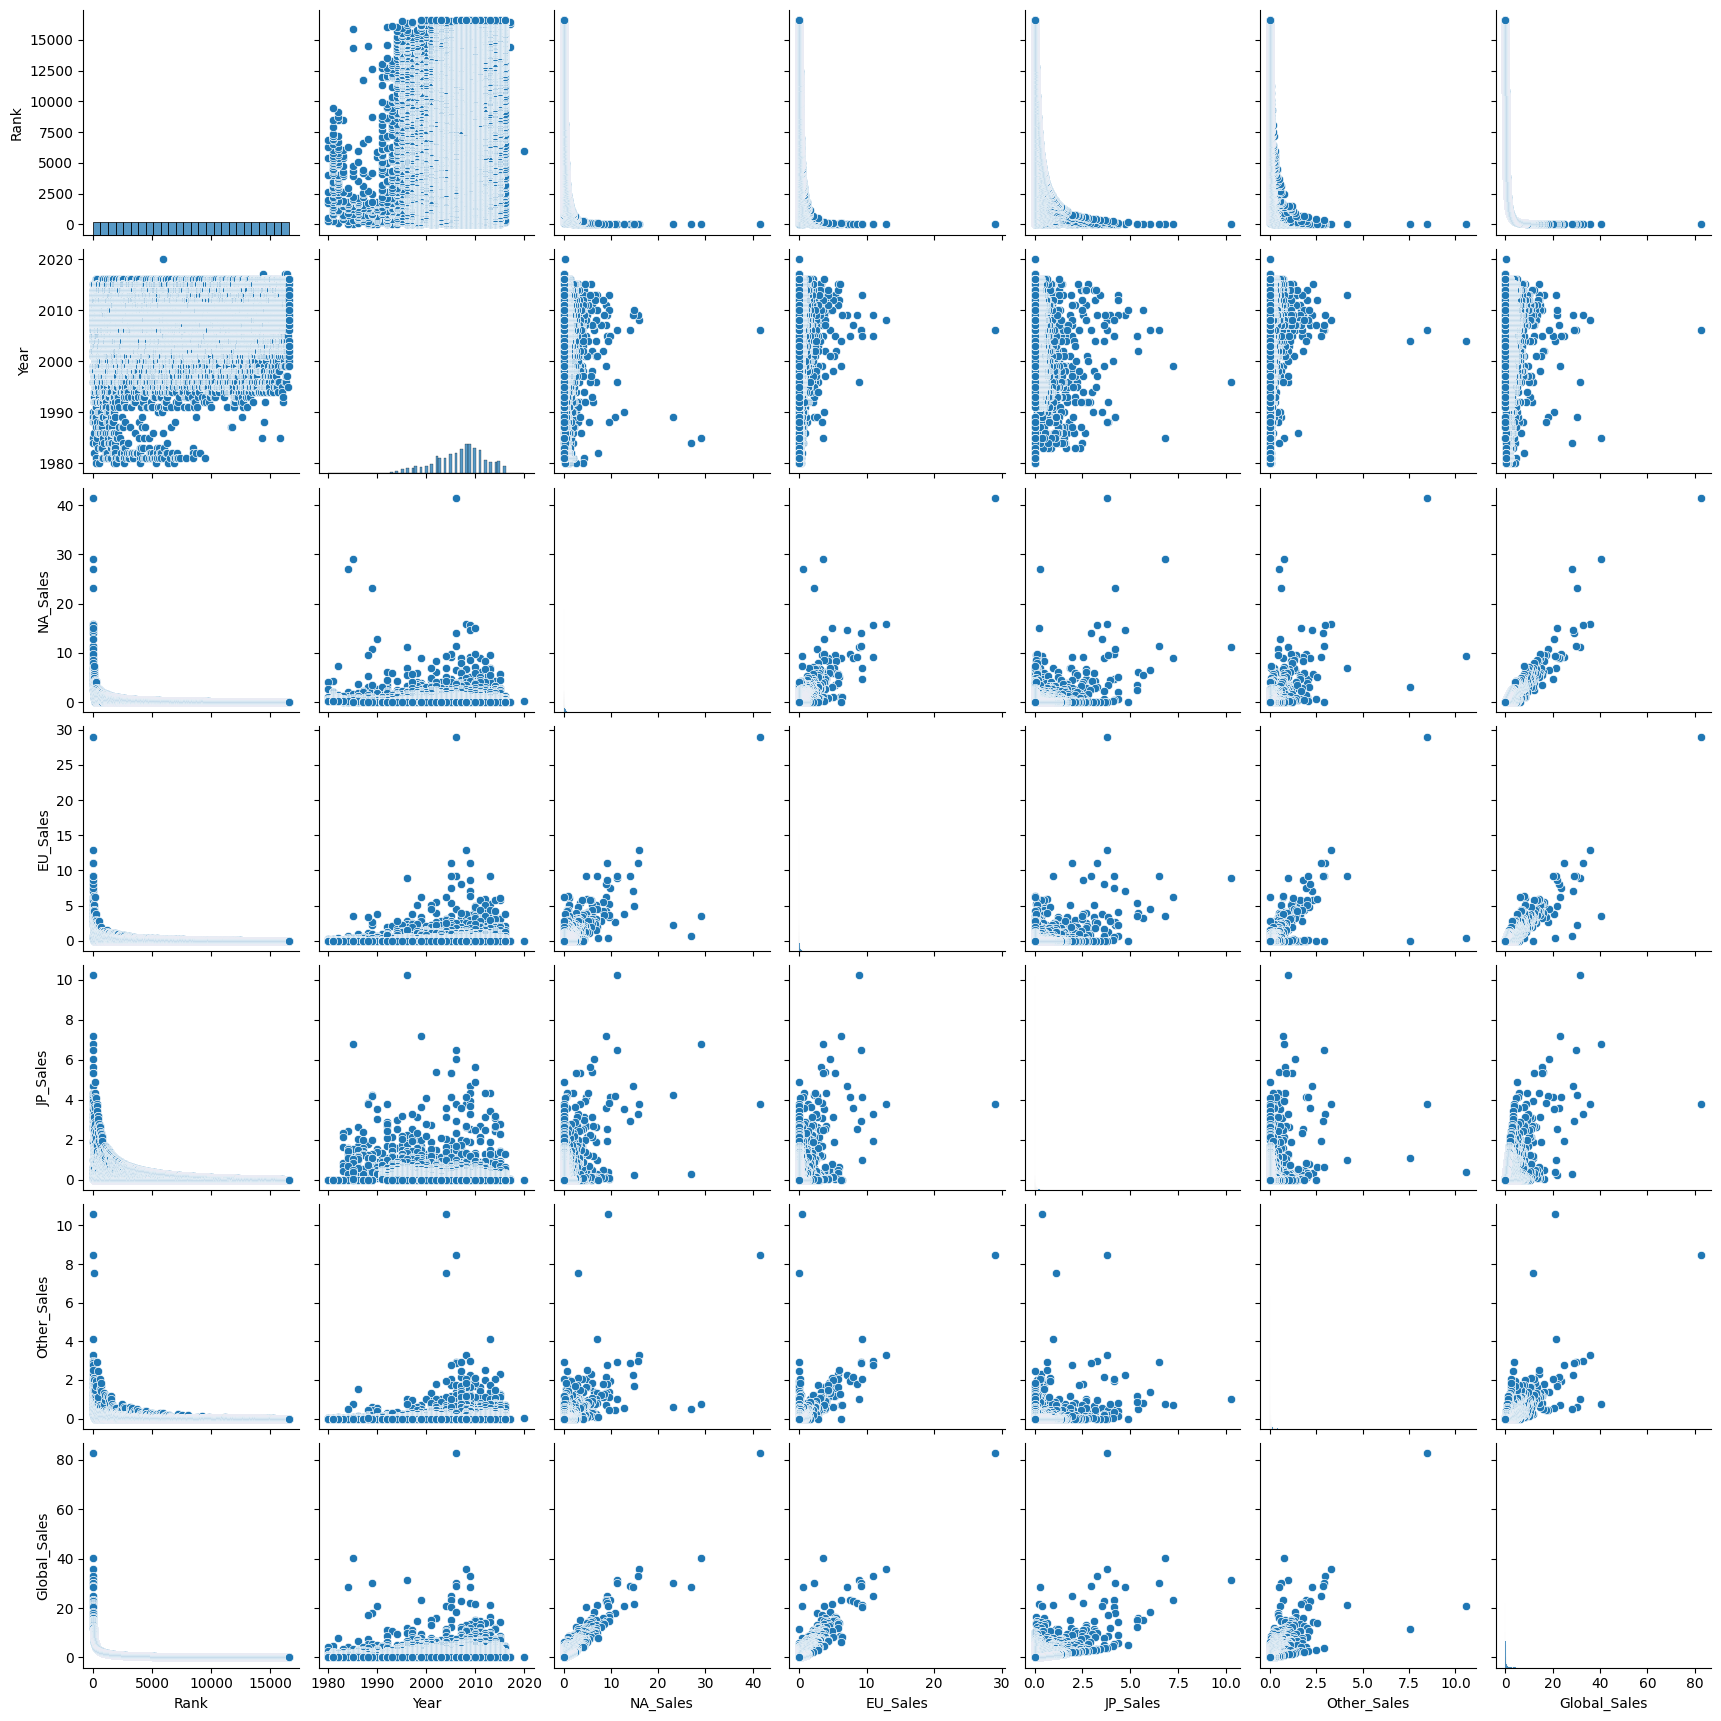

In [40]:
sns.pairplot(df)
plt.show()

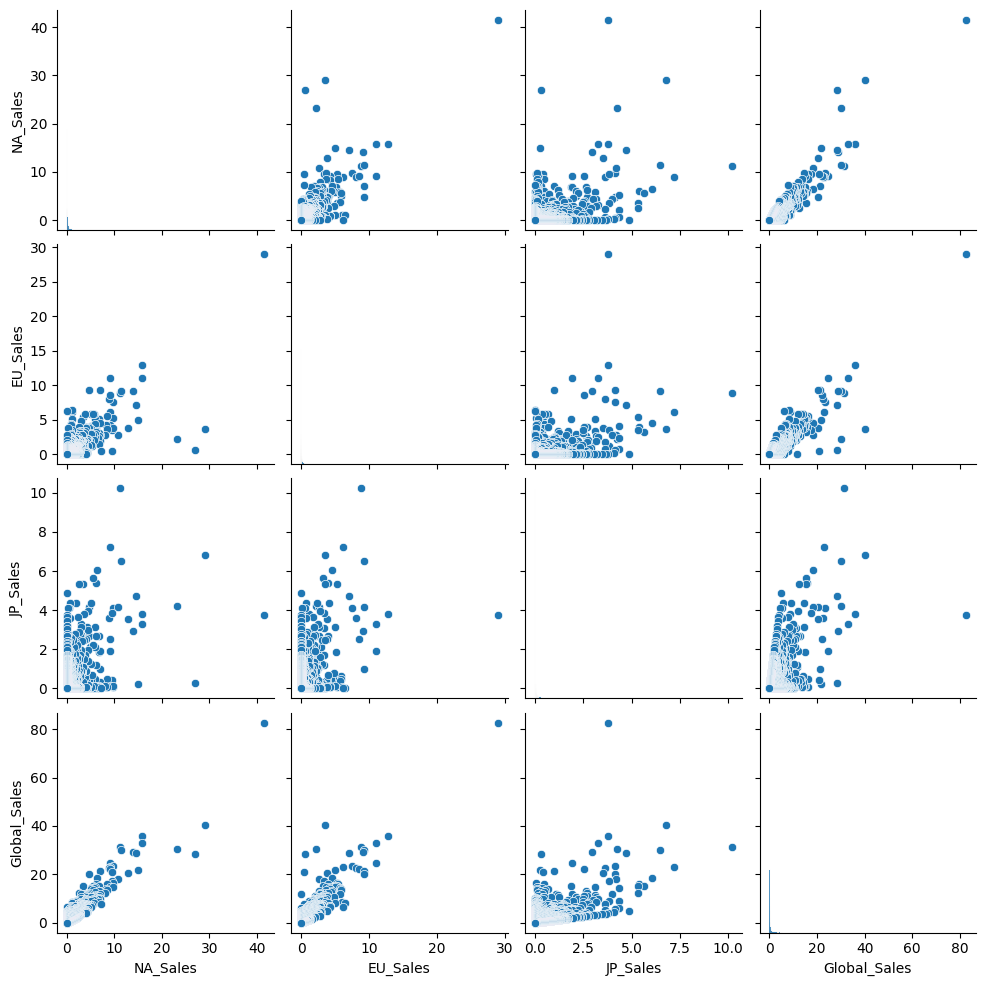

In [41]:
## Example — Sales Relationships

sns.pairplot(
    df[[
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Global_Sales"
    ]]
)

plt.show()


### What This Creates

You will see a grid like:

```
            NA     EU     JP     Global
NA        hist   scatter scatter scatter
EU        scatter hist   scatter scatter
JP        scatter scatter hist   scatter
Global    scatter scatter scatter hist
```

* **Diagonal → distributions**
* **Off-diagonal → scatter relationships**

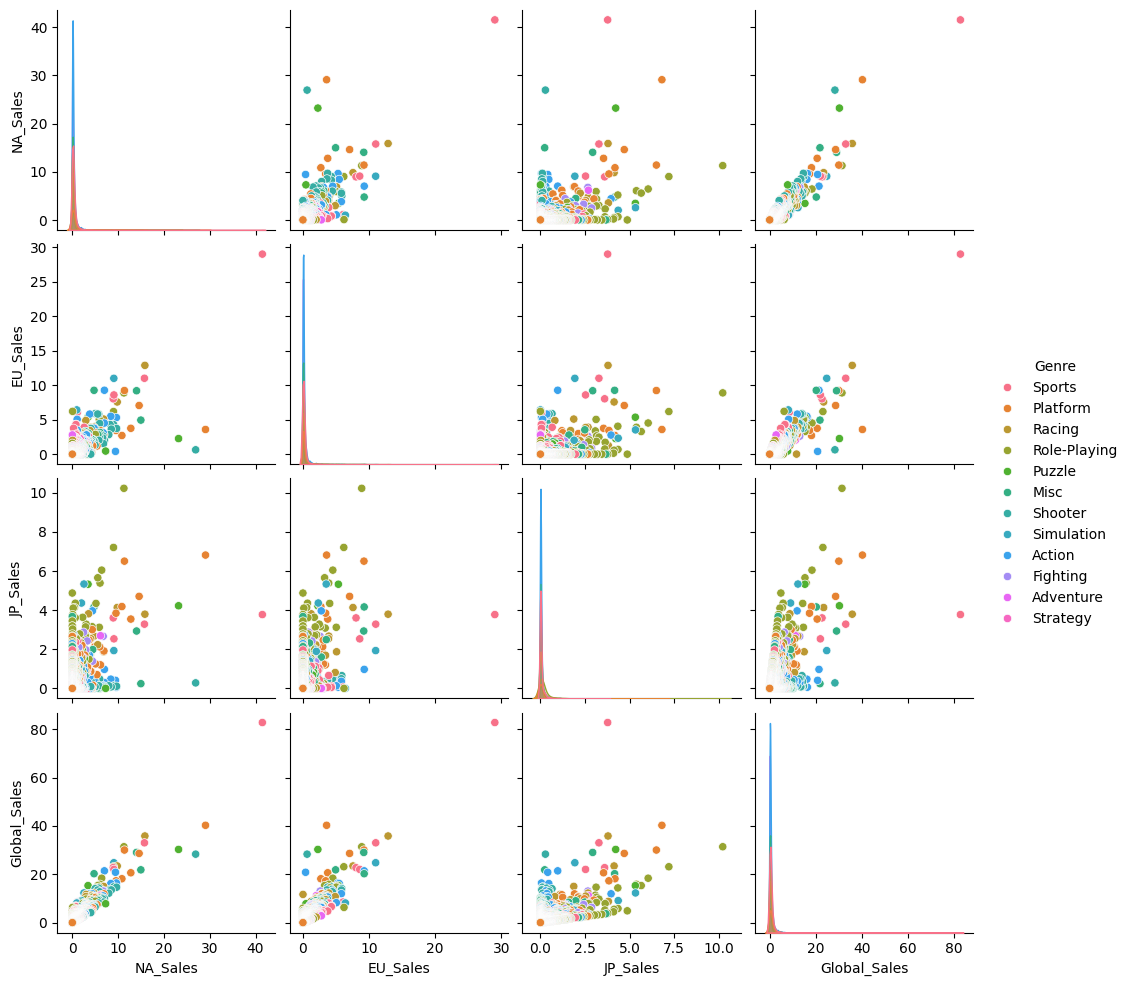

In [42]:
# Coloring by any category

sns.pairplot(
    df[[
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Global_Sales",
        "Genre"
    ]],
    hue="Genre"
)

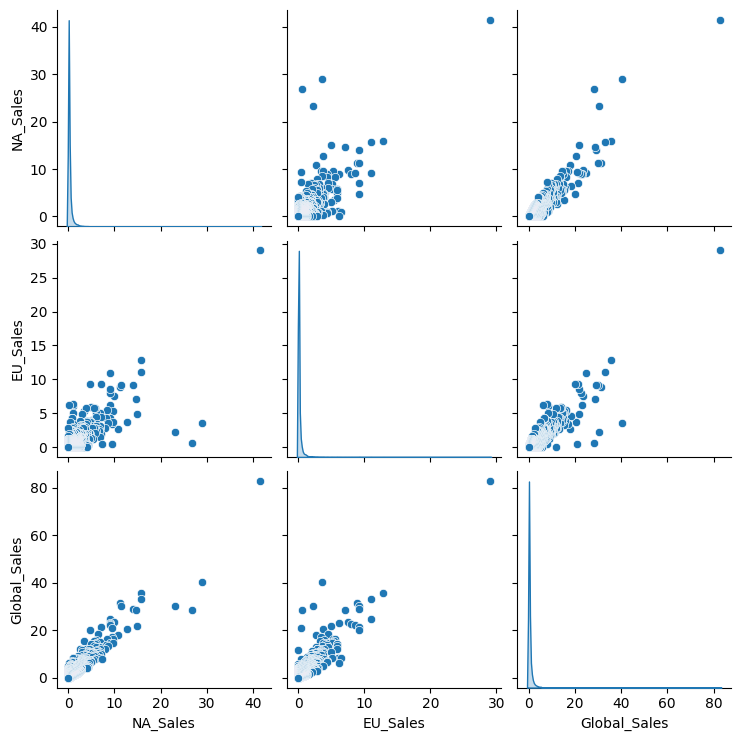

In [ ]:
# Adding KDE on diagonal distributions
sns.pairplot(
    df[[
        "NA_Sales",
        "EU_Sales",
        "Global_Sales"
    ]],
    diag_kind="kde"
)

### When to Use Pairplot

Use it when you want to:

* quickly explore relationships between multiple variables
* detect clusters
* see correlation patterns
* understand distributions